<a href="https://colab.research.google.com/github/tukamilano/Semi-Thue/blob/main/Levenshtein_best_first_search%E3%81%AE%E5%AE%9F%E9%A8%93.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ルールの重複は許すことにする

In [ ]:
!pip -q install python-Levenshtein pandas

[50/1000] elapsed=9.5s, rate=5.26 t/s
[100/1000] elapsed=19.6s, rate=5.11 t/s
[150/1000] elapsed=26.6s, rate=5.64 t/s
[200/1000] elapsed=35.6s, rate=5.61 t/s
[250/1000] elapsed=42.3s, rate=5.91 t/s
[300/1000] elapsed=50.4s, rate=5.95 t/s
[350/1000] elapsed=57.3s, rate=6.11 t/s
[400/1000] elapsed=64.5s, rate=6.21 t/s
[450/1000] elapsed=69.7s, rate=6.46 t/s
[500/1000] elapsed=76.6s, rate=6.53 t/s
[550/1000] elapsed=82.0s, rate=6.70 t/s
[600/1000] elapsed=89.2s, rate=6.73 t/s
[650/1000] elapsed=93.6s, rate=6.94 t/s
[700/1000] elapsed=97.7s, rate=7.16 t/s
[750/1000] elapsed=102.6s, rate=7.31 t/s
[800/1000] elapsed=106.2s, rate=7.53 t/s
[850/1000] elapsed=109.8s, rate=7.74 t/s
[900/1000] elapsed=113.9s, rate=7.90 t/s
[950/1000] elapsed=116.4s, rate=8.16 t/s
[1000/1000] elapsed=118.9s, rate=8.41 t/s
Done. Results appended to: /content/bfs_experiments/results_sweep_rule_num.csv


,rule_num,success_rate,expanded_mean,expanded_std,selected_mean,selected_std,n_trials,steps_mean,steps_std,expanded_mean_success,selected_mean_success,n_success,exp_per_step,sel_per_step
0,100,0.03,97000.00,17144.660800,168.76,187.802987,100,0.000000,0.000000,0.000000,0.000000,3,NaN,NaN
1,200,0.05,95000.56,21901.838322,138.60,125.339136,100,0.400000,0.547723,11.200000,0.400000,5,28.000000,1.0
2,300,0.11,89208.05,30913.942340,127.04,104.315171,100,7.363636,22.437793,1891.363636,7.363636,11,256.851852,1.0
3,400,0.12,88046.45,32533.645203,130.60,108.923752,100,2.416667,1.975225,387.083333,2.416667,12,160.172414,1.0
4,500,0.25,75991.47,42439.839268,116.78,105.349690,100,10.480000,34.083378,3965.880000,10.480000,25,378.423664,1.0
5,600,0.23,77883.79,41063.761749,105.19,80.578677,100,6.434783,14.301386,3842.565217,6.434783,23,597.155405,1.0
6,700,0.43,59860.00,47048.645764,76.15,78.554154,100,12.953488,22.533524,6651.162791,12.953488,43,513.464991,1.0
7,800,0.58,49478.28,45840.230611,57.46,64.498284,100,16.689655,22.762856,12893.586207,16.689655,58,772.549587,1.0
8,900,0.62,44374.62,46154.637782,46.19,55.224372,100,13.209677,20.623985,10281.645161,13.209677,62,778.341880,1.0
9,1000,0.78,31103.37,40665.442379,30.29,41.705871,100,12.846154,18.479246,11670.987179,12.846154,78,908.519960,1.0


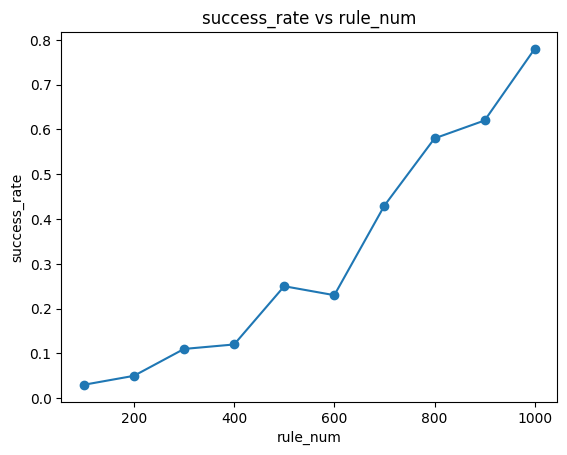

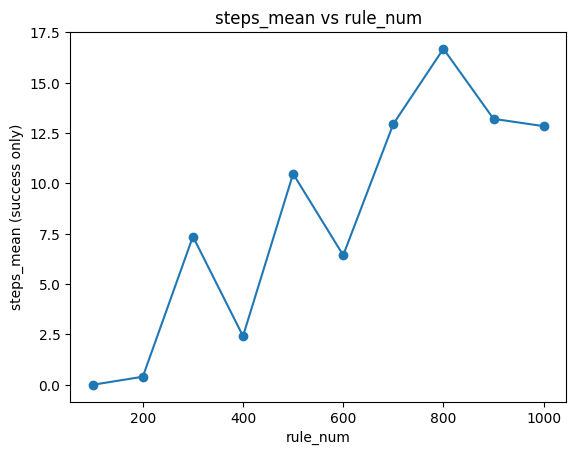

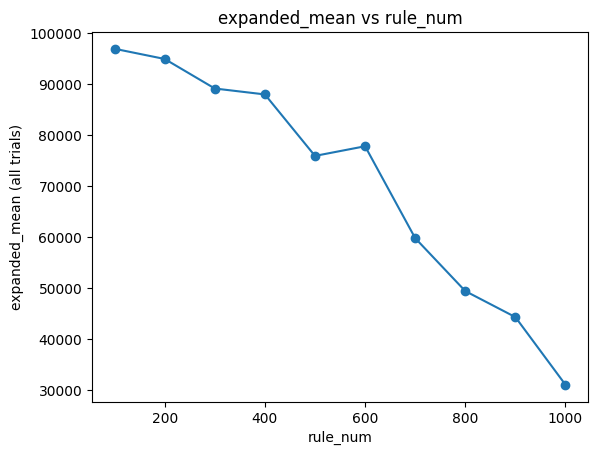

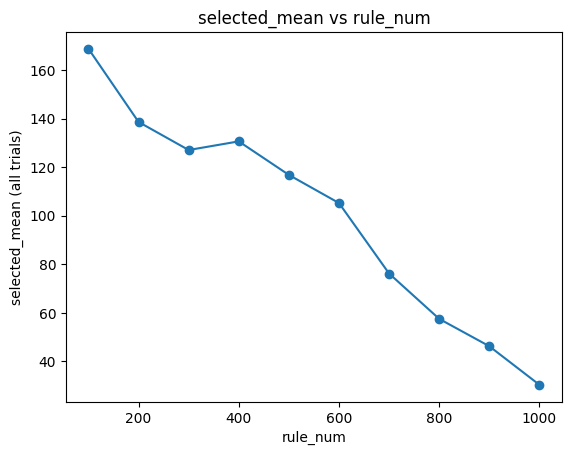

In [ ]:
import os, time, random, csv, itertools, heapq
from typing import List, Tuple, Dict
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from Levenshtein import distance as levenshtein_distance

# =========================
# 基本設定
# =========================
SEARCH_MODE   = "local"   # "gbfs" | "bfs" | "local" | "beam"
ALLOW_EPSILON_LHS = True
ALLOW_EPSILON_RHS = True
MAX_LEN_BFS   = 256
BEAM_WIDTH = 10
THRESHOLD_EXPANSIONS = 100000
LOG_EVERY     = 50
FLUSH_EVERY   = 100
OVERWRITE     = True

OUTPUT_DIR_LOCAL = f"/content/bfs_experiments"
BASE_DIR = OUTPUT_DIR_LOCAL
os.makedirs(BASE_DIR, exist_ok=True)

# =========================
# 文字・ルール生成
# =========================
def make_alphabet(alphabet_num: int) -> Tuple[str, ...]:
    return tuple(chr(65 + i) for i in range(alphabet_num))

def sample_geometric_len(p: float) -> int:
    i = 0
    while True:
        if random.random() < p:
            return i
        i += 1

def generate_rules(alphabet: Tuple[str, ...], rule_num: int, p: float) -> List[Tuple[str, str]]:
    rules = set()
    while len(rules) < rule_num:
        i = sample_geometric_len(p)
        j = sample_geometric_len(p)
        if (not ALLOW_EPSILON_LHS and i == 0) or (not ALLOW_EPSILON_RHS and j == 0):
            continue
        before = ''.join(random.choices(alphabet, k=i))
        after  = ''.join(random.choices(alphabet, k=j))
        if before == after:
            continue
        rules.add((before, after))
    return list(rules)

# =========================
# 探索アルゴリズム
# =========================
def search_gbfs(before: str, after: str, rules, *, threshold: int = 100000):
    if before == after:
        return 0, 0, 'success', 0
    searched = {before}
    node_expanded = 0
    selected_nodes = 0
    pq = [(levenshtein_distance(before, after), 0, before)]
    while pq:
        h, depth, current = heapq.heappop(pq)
        selected_nodes += 1
        for rb, ra in rules:
            blen = len(rb)
            if blen == 0:
                positions = range(len(current)+1)
            else:
                if len(current) < blen:
                    continue
                positions = range(len(current)-blen+1)
            for pos in positions:
                if current[pos:pos+blen] == rb:
                    new = current[:pos] + ra + current[pos+blen:]
                    if new in searched:
                        continue
                    searched.add(new)
                    node_expanded += 1
                    if new == after:
                        return depth+1, node_expanded, 'success', selected_nodes
                    heapq.heappush(pq, (levenshtein_distance(new, after), depth+1, new))
                    if node_expanded >= threshold:
                        return None, node_expanded, 'threshold', selected_nodes
    return None, node_expanded, 'unreachable', selected_nodes

def search_bfs(before: str, after: str, rules, *, threshold: int = 100000):
    if before == after:
        return 0, 0, 'success', 0
    visited = {before}
    q = deque([(before, 0)])
    node_expanded = 0
    selected_nodes = 0
    while q:
        current, depth = q.popleft()
        selected_nodes += 1
        for rb, ra in rules:
            blen = len(rb)
            if blen == 0:
                positions = range(len(current)+1)
            else:
                if len(current) < blen:
                    continue
                positions = range(len(current)-blen+1)
            for pos in positions:
                if current[pos:pos+blen] == rb:
                    new = current[:pos] + ra + current[pos+blen:]
                    if new in visited:
                        continue
                    visited.add(new)
                    node_expanded += 1
                    if new == after:
                        return depth+1, node_expanded, 'success', selected_nodes
                    q.append((new, depth+1))
                    if node_expanded >= threshold:
                        return None, node_expanded, 'threshold', selected_nodes
    return None, node_expanded, 'unreachable', selected_nodes

def search_local(before: str, after: str, rules, *, threshold: int = 100000):
    if before == after:
        return 0, 0, 'success', 0
    current = before
    node_expanded = 0
    selected_nodes = 0
    steps = 0
    while True:
        best_h = None
        best_neighbors = []
        for rb, ra in rules:
            blen = len(rb)
            if blen == 0:
                positions = range(len(current)+1)
            else:
                if len(current) < blen:
                    continue
                positions = range(len(current)-blen+1)
            for pos in positions:
                if current[pos:pos+blen] == rb:
                    nxt = current[:pos] + ra + current[pos+blen:]
                    if nxt == after:
                        node_expanded += 1
                        selected_nodes += 1
                        return steps + 1, node_expanded, 'success', selected_nodes
                    h = levenshtein_distance(nxt, after)
                    node_expanded += 1
                    if best_h is None or h < best_h:
                        best_h = h; best_neighbors = [nxt]
                    elif h == best_h:
                        best_neighbors.append(nxt)
                    if node_expanded >= threshold:
                        return None, node_expanded, 'threshold', selected_nodes
        if best_h is None or not best_neighbors:
            return None, node_expanded, 'dead_end', selected_nodes
        current = random.choice(best_neighbors)
        steps += 1
        selected_nodes += 1
        if node_expanded >= threshold:
            return None, node_expanded, 'threshold', selected_nodes

def search_beam(before: str, after: str, rules, *, beam_width: int = 10, threshold: int = 100000):
    bw = max(1, int(beam_width))
    if before == after:
        return 0, 0, 'success', 0

    node_expanded = 0
    selected_nodes = 0
    steps = 0
    visited = {before}
    beam = [before]

    while beam:
        steps += 1
        candidates = []
        for current in beam:
            for rb, ra in rules:
                blen = len(rb)
                if blen == 0:
                    positions = range(len(current)+1)
                else:
                    if len(current) < blen:
                        continue
                    positions = range(len(current)-blen+1)
                for pos in positions:
                    if current[pos:pos+blen] == rb:
                        new = current[:pos] + ra + current[pos+blen:]
                        if new in visited:
                            continue
                        visited.add(new)
                        node_expanded += 1
                        if new == after:
                            return steps, node_expanded, 'success', selected_nodes
                        candidates.append((levenshtein_distance(new, after), new))
                        if node_expanded >= threshold:
                            return None, node_expanded, 'threshold', selected_nodes
        if not candidates:
            return None, node_expanded, 'dead_end', selected_nodes
        candidates.sort(key=lambda x: x[0])
        beam = [state for _, state in candidates[:bw]]
        selected_nodes += len(beam)
    return None, node_expanded, 'threshold', selected_nodes

# =========================
# ディスパッチ
# =========================
def run_search(mode: str, before: str, after: str, rules, **kw):
    if mode == "gbfs":
        return search_gbfs(before, after, rules, threshold=kw.get("threshold", 100000))
    elif mode == "bfs":
        return search_bfs(before, after, rules, threshold=kw.get("threshold", 100000))
    elif mode == "local":
        return search_local(before, after, rules, threshold=kw.get("threshold", 100000))
    elif mode == "beam":
        return search_beam(before, after, rules, beam_width=kw.get("beam_width", 10), threshold=kw.get("threshold", 100000))
    else:
        raise ValueError(f"Unknown SEARCH_MODE: {mode}")

# =========================
# 単一試行
# =========================
def run_one_trial(alphabet_num: int, rule_num: int, p: float, seed: int, threshold: int) -> Dict:
    random.seed(seed)
    alphabet = make_alphabet(alphabet_num)
    rules = generate_rules(alphabet, rule_num, p)
    i = sample_geometric_len(p)
    j = sample_geometric_len(p)
    before = ''.join(random.choices(alphabet, k=i))
    after  = ''.join(random.choices(alphabet, k=j))

    t0 = time.time()
    if SEARCH_MODE == "bfs":
        steps, node_expanded, term, selected_nodes = run_search("bfs", before, after, rules, threshold=threshold, max_len=MAX_LEN_BFS)
    elif SEARCH_MODE == "local":
        steps, node_expanded, term, selected_nodes = run_search("local", before, after, rules, threshold=threshold)
    elif SEARCH_MODE == "gbfs":
        steps, node_expanded, term, selected_nodes = run_search("gbfs", before, after, rules, threshold=threshold)
    else:
        steps, node_expanded, term, selected_nodes = run_search("beam", before, after, rules, threshold=threshold, beam_width=BEAM_WIDTH)

    elapsed = time.time() - t0

    return dict(
        alphabet_num=alphabet_num,
        rule_num=rule_num,
        rule_length_expect_inv=p,
        seed=seed,
        threshold=threshold,
        before_len=len(before),
        after_len=len(after),
        success=1 if term == 'success' else 0,
        termination=term,
        steps=int(steps) if steps is not None else -1,
        node_expanded=int(node_expanded),
        selected_nodes=int(selected_nodes),
        elapsed_sec=elapsed
    )

# =========================
# CSVユーティリティ & 集計
# =========================
def ensure_csv_header(path: str, fieldnames: List[str]):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        with open(path, "w", newline="") as f:
            csv.DictWriter(f, fieldnames=fieldnames).writeheader()

def append_rows(path: str, rows: List[Dict], fieldnames: List[str]):
    if not rows:
        return
    with open(path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writerows(rows)

def summarize_results(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    keys = ["alphabet_num","rule_num","rule_length_expect_inv"]
    g_all  = df.groupby(keys).agg(
        success_rate=("success","mean"),
        expanded_mean=("node_expanded","mean"),
        expanded_std =("node_expanded","std"),
        selected_mean=("selected_nodes","mean"),
        selected_std =("selected_nodes","std"),
        n_trials=("success","count")
    )
    g_succ = df[df["success"]==1].groupby(keys).agg(
        steps_mean=("steps","mean"),
        steps_std =("steps","std"),
        expanded_mean_success=("node_expanded","mean"),
        selected_mean_success=("selected_nodes","mean"),
        n_success=("success","count"),
    )
    summary = g_all.join(g_succ, how="left").reset_index()
    summary["exp_per_step"] = summary["expanded_mean_success"] / summary["steps_mean"]
    summary["sel_per_step"] = summary["selected_mean_success"] / summary["steps_mean"]
    return summary

def plot_sweep(summary: pd.DataFrame, vary_param: str):
    x = summary[vary_param].values
    plt.figure(); plt.plot(x, summary["success_rate"].values, marker='o')
    plt.xlabel(vary_param); plt.ylabel("success_rate"); plt.title(f"success_rate vs {vary_param}")
    plt.show()
    if "steps_mean" in summary and summary["steps_mean"].notna().any():
        plt.figure(); plt.plot(x, summary["steps_mean"].values, marker='o')
        plt.xlabel(vary_param); plt.ylabel("steps_mean (success only)"); plt.title(f"steps_mean vs {vary_param}")
        plt.show()
    plt.figure(); plt.plot(x, summary["expanded_mean"].values, marker='o')
    plt.xlabel(vary_param); plt.ylabel("expanded_mean (all trials)"); plt.title(f"expanded_mean vs {vary_param}")
    plt.show()
    plt.figure(); plt.plot(x, summary["selected_mean"].values, marker='o')
    plt.xlabel(vary_param); plt.ylabel("selected_mean (all trials)"); plt.title(f"selected_mean vs {vary_param}")
    plt.show()

# =========================
# A) グリッド一括スイープ
# =========================
ALPHABET_NUM_GRID = [10, 25]
RULE_NUM_GRID     = [300, 600]
P_GRID            = [0.2, 0.3]
TRIALS_PER_SETTING_GRID = 100
OUTPUT_CSV_GRID = os.path.join(BASE_DIR, "results_grid.csv")

def run_experiments_grid():
    if OVERWRITE and os.path.exists(OUTPUT_CSV_GRID):
        os.remove(OUTPUT_CSV_GRID)
    fieldnames = [
        "alphabet_num","rule_num","rule_length_expect_inv","seed","threshold",
        "before_len","after_len","success","termination","steps",
        "node_expanded","selected_nodes","elapsed_sec"
    ]
    ensure_csv_header(OUTPUT_CSV_GRID, fieldnames)
    combos = list(itertools.product(ALPHABET_NUM_GRID, RULE_NUM_GRID, P_GRID))
    total = len(combos) * TRIALS_PER_SETTING_GRID
    pending, done = [], 0
    t0 = time.time()
    for (a, r, p) in combos:
        base_seed = random.randrange(10**9)
        for t in range(TRIALS_PER_SETTING_GRID):
            seed = (base_seed + 1315423911 * (t+1)) & 0x7fffffff
            rec = run_one_trial(a, r, p, seed, THRESHOLD_EXPANSIONS)
            pending.append(rec); done += 1
            if len(pending) >= FLUSH_EVERY or done == total:
                append_rows(OUTPUT_CSV_GRID, pending, fieldnames); pending.clear()
            if done % LOG_EVERY == 0 or done == total:
                elapsed = time.time() - t0
                rate = done / max(elapsed, 1e-9)
                print(f"[{done}/{total}] elapsed={elapsed:.1f}s, rate={rate:.2f} t/s")
    print("Done. Results appended to:", OUTPUT_CSV_GRID)
    summary = summarize_results(OUTPUT_CSV_GRID)
    display(summary.sort_values(["alphabet_num","rule_num","rule_length_expect_inv"]))

# =========================
# B) 1変数スイープ
# =========================
VARY_PARAM  = "rule_num"
VARY_VALUES = [100 * x for x in range(1,11)]
FIXED_CONFIG = {"alphabet_num": 25, "rule_num": 600, "p": 0.20}
TRIALS_PER_SETTING_SWEEP = 100
OUTPUT_CSV_SWEEP = os.path.join(BASE_DIR, f"results_sweep_{VARY_PARAM}.csv")

def _make_combination(vary_param, vary_values, fixed):
    combos = []
    for v in vary_values:
        a = fixed["alphabet_num"]; r = fixed["rule_num"]; p = fixed["p"]
        if vary_param == "alphabet_num": a = int(v)
        elif vary_param == "rule_num":    r = int(v)
        elif vary_param == "p":           p = float(v)
        else: raise ValueError("VARY_PARAM must be 'alphabet_num', 'rule_num', or 'p'")
        combos.append((a, r, p))
    return combos

def run_experiments_sweep():
    if OVERWRITE and os.path.exists(OUTPUT_CSV_SWEEP):
        os.remove(OUTPUT_CSV_SWEEP)
    fieldnames = [
        "alphabet_num","rule_num","rule_length_expect_inv","seed","threshold",
        "before_len","after_len","success","termination","steps",
        "node_expanded","selected_nodes","elapsed_sec"
    ]
    ensure_csv_header(OUTPUT_CSV_SWEEP, fieldnames)
    combos = _make_combination(VARY_PARAM, VARY_VALUES, FIXED_CONFIG)
    total = len(combos) * TRIALS_PER_SETTING_SWEEP
    pending, done = [], 0
    t0 = time.time()
    for (a, r, p) in combos:
        base_seed = random.randrange(10**9)
        for t in range(TRIALS_PER_SETTING_SWEEP):
            seed = (base_seed + 2654435761 * (t+1)) & 0x7fffffff
            rec = run_one_trial(a, r, p, seed, THRESHOLD_EXPANSIONS)
            pending.append(rec); done += 1
            if len(pending) >= FLUSH_EVERY or done == total:
                append_rows(OUTPUT_CSV_SWEEP, pending, fieldnames); pending.clear()
            if done % LOG_EVERY == 0 or done == total:
                elapsed = time.time() - t0
                rate = done / max(elapsed, 1e-9)
                print(f"[{done}/{total}] elapsed={elapsed:.1f}s, rate={rate:.2f} t/s")
    print("Done. Results appended to:", OUTPUT_CSV_SWEEP)

def summarize_sweep(path: str, vary_param: str, fixed: dict) -> pd.DataFrame:
    df = pd.read_csv(path)
    mask = (
        ((df["alphabet_num"] == fixed["alphabet_num"]) if vary_param != "alphabet_num" else True) &
        ((df["rule_num"]     == fixed["rule_num"])     if vary_param != "rule_num"     else True) &
        ((df["rule_length_expect_inv"] == fixed["p"])  if vary_param != "p"             else True)
    )
    dff = df[mask].copy()
    key = {"alphabet_num":"alphabet_num","rule_num":"rule_num","p":"rule_length_expect_inv"}[vary_param]
    g_all  = dff.groupby([key]).agg(
        success_rate=("success","mean"),
        expanded_mean=("node_expanded","mean"),
        expanded_std =("node_expanded","std"),
        selected_mean=("selected_nodes","mean"),
        selected_std =("selected_nodes","std"),
        n_trials=("success","count")
    )
    g_succ = dff[dff["success"]==1].groupby([key]).agg(
        steps_mean=("steps","mean"),
        steps_std =("steps","std"),
        expanded_mean_success=("node_expanded","mean"),
        selected_mean_success=("selected_nodes","mean"),
        n_success=("success","count"),
    )
    summary = g_all.join(g_succ, how="left").reset_index().rename(columns={"rule_length_expect_inv":"p"})
    summary["exp_per_step"] = summary["expanded_mean_success"] / summary["steps_mean"]
    summary["sel_per_step"] = summary["selected_mean_success"] / summary["steps_mean"]
    return summary.sort_values(by={"alphabet_num":"alphabet_num","rule_num":"rule_num","p":"p"}[vary_param])

# ===== 実行例 =====
run_experiments_sweep()
summary = summarize_sweep(OUTPUT_CSV_SWEEP, VARY_PARAM, FIXED_CONFIG)
display(summary)
plot_sweep(summary, VARY_PARAM)
